# Compact Multi-Hop GNN for Xanthine Oxidase (XO) Inhibitor Screening
Colab-ready. Small-data-safe classification pipeline: XO labelled set (~645) -> Morgan baselines -> GCN/GIN/GAT + proposed compact multi-hop (1/2/3-hop + learned weighting) -> ablation -> repeated CV -> freeze -> COCONUT screen -> AD + diversity -> docking-ready export.

> Run top-to-bottom on Colab (GPU optional but recommended). Replace `xo_dataset.csv` with your curated XO set to leave DEMO mode.


In [52]:
# 0. Dependencies (Colab). Re-run if runtime restarts.
# TIP: Runtime > Change runtime type > T4 GPU before running.
# FREE-TIER: T4 15GB VRAM / ~12GB RAM / 2 vCPU / idle-timeout. Keep batches small, stream COCONUT.
%env PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:128
!nvidia-smi 2>&1 | head -n 12
!pip install -q "torch>=2.2" "torch-geometric>=2.5" "rdkit>=2023.09" "scikit-learn" "seaborn" "tqdm" "gdown" "xgboost" "chembl_webresource_client" 2>&1 | tail -n 3


env: PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:128
Tue Oct  6 05:19:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P0             27W /   70W |     167MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A

## 1. Imports, device, seeds

In [53]:
import os, random, math, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, GATConv, global_mean_pool, global_add_pool, global_max_pool
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score, precision_score,
                             recall_score, f1_score, matthews_corrcoef, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except Exception as e:
    HAVE_XGB = False
    print("xgboost unavailable:", e)
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, FilterCatalog, rdFingerprintGenerator
from rdkit.RDLogger import DisableLog
DisableLog('rdApp.*')
# AMP uses torch.amp API (old cuda.amp path deprecated) — no warning filter needed

SEED = 57
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
# ---- Colab GPU setup (T4 / L4 / A100): CUDA + cudnn + AMP flag ----
USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda" if USE_CUDA else "cpu")
if USE_CUDA:
    torch.backends.cudnn.benchmark = True  # small fixed-size graphs -> faster convs
    try: torch.set_float32_matmul_precision("high")
    except Exception: pass
    torch.cuda.manual_seed_all(SEED)
    _gn, _gm = torch.cuda.get_device_name(0), torch.cuda.get_device_properties(0).total_memory/1e9
    print(f"device: cuda | {_gn} | VRAM {_gm:.1f}GB | torch {torch.__version__} | AMP={globals().get('USE_AMP', True)}")
else:
    print(f"device: CPU (no GPU!) | torch {torch.__version__} — set Runtime > Change runtime type > T4 GPU for ~5-10x speedup")
PIN_MEM = USE_CUDA  # DataLoader pin_memory only helps on CUDA
# ---- Free-Colab safety: cap CPU threads, DataLoader workers=0 (fork+RDKit unsafe) ----
FREE_TIER = True  # free (non-paid) Colab: 2 vCPU, ~12GB RAM, T4. Set False on paid/high-RAM runtimes.
NUM_WORKERS = 0  # keep 0 on Colab (multiprocessing DataLoader often hangs/OOMs with PyG+RDKit)
try:
    torch.set_num_threads(2); torch.set_num_interop_threads(2)
except Exception: pass
import gc
if USE_CUDA:
    torch.cuda.empty_cache()


device: cuda | Tesla T4 | VRAM 15.6GB | torch 2.11.0+cu130 | AMP=True


## 2. Config — define BEFORE modelling (no test-derived tuning)

In [54]:
# ---- Predefined scientific decisions (edit here, before running) ----
XO_CSV_CANDIDATES = ["xo_dataset.csv", "xo_xanthine_oxidase.csv",
  "Part_8/screening_results.csv",  # fallback chain only for DEMO structures, never labels
  "/home/bijay/Desktop/already read paper/new_method/testing/fix_of_chemphore/screening_results.csv"]
ACTIVE_THR_IC50_UM = 10.0   # IC50 <= 10 uM -> Active. Justify in thesis/paper; do NOT tune after seeing scores.
AGG_RULE = "median"         # if duplicate compound_id/canonical has multiple IC50s: median|max|min
TEST_SIZE = 0.20
VAL_SIZE = 0.15             # fraction of train-dev for early-stopping validation
N_REPEATS, N_SPLITS = 3, 5
HIDDEN = 64
DROPOUT = 0.3
WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 100
PATIENCE = 15
MIN_EPOCHS = 10  # no early-stop before this epoch (lets GNN escape majority-collapse)
BATCH = 64
MORGAN_NBITS = 512
HOPS = [1, 2, 3]
AD_TANIMOTO_CUT = 0.30      # COCONUT mol with max-Tanimoto < cut -> outside AD
TOP_FRAC = 0.01             # top 1% for docking shortlist (adjust to budget)
RF_THR = 0.6                # consensus with Morgan-RF (Arjun-style strict)
USE_AMP = True              # Colab GPU: mixed-precision (T4 safe, ~1.5-2x faster)
GPU_BATCH = 1024            # screening batch on CUDA (CPU fallback 512)
# ---- Free-tier overrides (VRAM/RAM safe on T4). Edit base values above; caps applied here. ----
if globals().get("FREE_TIER", True):
    GPU_BATCH = 256       # 1024 x variable-size graphs OOMs on T4 (100k+ nodes/batch); 256 safe
    BATCH = 64            # train batch stays small (645 compounds, stable grads)
    SCREEN_CHUNK = 8192  # stream COCONUT: featurize+infer per chunk so RAM never holds 154k graphs
    AD_TRAIN_SAMPLE = 1500  # cap Tanimoto reference set (full train x 154k pairs = slow + huge IPC)
    EPOCHS = min(EPOCHS, 60)  # early-stop usually hits <40; cap keeps free-tier runtime < timeout
else:
    SCREEN_CHUNK = 16384; AD_TRAIN_SAMPLE = 5000
print(f"ACTIVE_THR={ACTIVE_THR_IC50_UM}uM | TEST {TEST_SIZE} | HIDDEN {HIDDEN} | HOPS {HOPS}")

# ---- ChEMBL fetch (Arjun Part_1 style, but XO target) ----
USE_CHEMBL_FETCH = True  # set False to skip network and use local/demo only
XO_TARGET_CHEMBL_ID = "CHEMBL1929"  # human Xanthine dehydrogenase/oxidase (XDH, UniProt P47989); mouse=CHEMBL5465298, rat=CHEMBL1075246
XO_STANDARD_TYPE = "IC50"  # keep IC50 only for consistent units; Ki handled separately if needed


ACTIVE_THR=10.0uM | TEST 0.2 | HIDDEN 64 | HOPS [1, 2, 3]


In [55]:
# 2b. Cache + parallel helpers — reruns reuse saved data (fast), recompute only if inputs/config change
import os, json, hashlib, pickle
import concurrent.futures as cf
# Persistence: Colab /content is EPHEMERAL — xo_cache there speeds up reruns only
# within the same runtime. Set USE_DRIVE=True to keep caches in Google Drive
# across sessions (survives timeouts/recycles; slightly slower I/O).
USE_DRIVE = False
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        CACHE_DIR = "/content/drive/MyDrive/xo_cache_colab"
    except Exception as e:
        print(f"Drive mount failed ({e}) — falling back to local xo_cache")
        CACHE_DIR = "xo_cache"
else:
    CACHE_DIR = "xo_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
REUSE_CACHE = True   # set False to force recompute everything
FORCE_REFETCH = False  # set True to re-query ChEMBL even if xo_bioactivity_raw.csv exists
FORCE_RECOMPUTE = False  # set True to ignore all caches
if globals().get("FREE_TIER", True):
    N_JOBS = max(1, min(2, (os.cpu_count() or 2)))  # free Colab: 2 vCPU; more workers => RAM fork-blowup
else:
    N_JOBS = max(1, min(8, (os.cpu_count() or 4) - 1))
print(f"cache dir: {CACHE_DIR} | REUSE={REUSE_CACHE} | N_JOBS={N_JOBS} | cpu={os.cpu_count()}")

def _cfg_hash(obj):
    return hashlib.md5(json.dumps(obj, sort_keys=True, default=str).encode()).hexdigest()[:10]

def _cache_hit(path):
    return REUSE_CACHE and (not FORCE_RECOMPUTE) and os.path.exists(path)

def _save_pickle(obj, path):
    open(path, "wb").write(pickle.dumps(obj))

def _load_pickle(path):
    return pickle.loads(open(path, "rb").read())

def _tload(path, **kw):
    # torch>=2.6 defaults weights_only=True (warns); old torch lacks the kwarg. State_dicts + {state,config,thr} both load under weights_only=True.
    import torch as _torch
    try:
        # safe payloads (state_dicts, dicts of tensors/str/float) load warning-free on torch>=2.6
        return _torch.load(path, map_location="cpu", weights_only=True, **kw)
    except Exception:
        # PyG Data graphs + old torch: fall back to legacy unrestricted load (same as before)
        kw.pop("weights_only", None)
        try:
            return _torch.load(path, map_location="cpu", weights_only=False, **kw)
        except TypeError:
            return _torch.load(path, map_location="cpu", **kw)

# ---- top-level workers (picklable for multiprocessing) ----
def _std_one(smi):
    try:
        from rdkit import Chem
        m = Chem.MolFromSmiles(str(smi))
        if m is None: return None
        frags = Chem.GetMolFrags(m, asMols=True)
        if len(frags) > 1:
            m = max(frags, key=lambda x: x.GetNumAtoms())
        Chem.SanitizeMol(m)
        return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
    except Exception:
        return None

def _fp_one(args):
    smi, radius, nbits = args
    try:
        import numpy as np
        from rdkit import Chem, DataStructs
        from rdkit.Chem import rdFingerprintGenerator
        m = Chem.MolFromSmiles(smi)
        if m is None:
            return np.zeros(nbits, dtype=np.float32)
        gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nbits)
        fp = gen.GetFingerprint(m)
        arr = np.zeros(nbits, dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except Exception:
        import numpy as np
        return np.zeros(nbits, dtype=np.float32)

def _medchem_one(smi):
    try:
        from rdkit import Chem
        from rdkit.Chem import Descriptors, FilterCatalog
        _pc = FilterCatalog.FilterCatalogParams()
        _pc.AddCatalog(FilterCatalog.FilterCatalogs.PAINS_A)
        _pains = FilterCatalog.FilterCatalog(_pc)
        m = Chem.MolFromSmiles(smi)
        if m is None: return False
        if _pains.HasMatch(m): return False
        mw, logp = Descriptors.MolWt(m), Descriptors.MolLogP(m)
        hbd, hba = Descriptors.NumHDonors(m), Descriptors.NumHAcceptors(m)
        return bool(mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10)
    except Exception:
        return False

def _tan_one(args):
    smi, train_bits, radius, nbits = args
    try:
        from rdkit import Chem, DataStructs
        from rdkit.Chem import rdFingerprintGenerator
        m = Chem.MolFromSmiles(smi)
        if m is None: return 0.0
        gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nbits)
        fp = gen.GetFingerprint(m)
        # train_bits are ExplicitBitVect objects (picklable); compare in worker
        best = 0.0
        for t in train_bits:
            s = DataStructs.TanimotoSimilarity(fp, t)
            if s > best: best = s
        return float(best)
    except Exception:
        return 0.0

def parallel_map(fn, items, desc="parallel", chunksize=200, use_proc=False):
    """Free-tier safe: ThreadPool default (RDKit fork-unsafe + big IPC). use_proc=True opts into ProcessPool."""
    n = len(items)
    if n == 0: return []
    if N_JOBS <= 1:
        from tqdm.auto import tqdm
        return [fn(x) for x in tqdm(items, desc=desc+" (seq)")]
    if (not use_proc) or globals().get("FREE_TIER", True):
        # threads: no pickling of big objects (fingerprints), safe on 2-vCPU free tier
        try:
            from tqdm.auto import tqdm
            import concurrent.futures as _cf2
            out = [None]*n
            with _cf2.ThreadPoolExecutor(max_workers=max(2, N_JOBS*2)) as ex:
                futs = {ex.submit(fn, x): i for i, x in enumerate(items)}
                for f in tqdm(_cf2.as_completed(futs), total=n, desc=desc+f" (x{max(2,N_JOBS*2)} thr)"):
                    out[futs[f]] = f.result()
            return out
        except Exception as e:
            print(f"thread pool failed ({e}), trying procs...")
    try:
        from tqdm.auto import tqdm
        out = [None]*n
        with cf.ProcessPoolExecutor(max_workers=N_JOBS) as ex:
            futs = {ex.submit(fn, x): i for i, x in enumerate(items)}
            for f in tqdm(cf.as_completed(futs), total=n, desc=desc+f" (x{N_JOBS} proc)"):
                out[futs[f]] = f.result()
        return out
    except Exception as e:
        print(f"ProcessPool failed ({e}) -> ThreadPool fallback")
        try:
            from tqdm.auto import tqdm
            out = [None]*n
            with cf.ThreadPoolExecutor(max_workers=N_JOBS*2) as ex:
                futs = {ex.submit(fn, x): i for i, x in enumerate(items)}
                for f in tqdm(cf.as_completed(futs), total=n, desc=desc+f" (x{N_JOBS*2} thr)"):
                    out[futs[f]] = f.result()
            return out
        except Exception as e2:
            print(f"ThreadPool failed ({e2}) -> sequential")
            from tqdm.auto import tqdm
            return [fn(x) for x in tqdm(items, desc=desc+" (seq-fallback)")]


cache dir: xo_cache | REUSE=True | N_JOBS=2 | cpu=2


## 3. Source XO dataset — load or DEMO mode

In [56]:
# 3a. Load order: xo_dataset.csv -> ChEMBL fetch (CHEMBL1929) -> DEMO
# Arjun Part_1 pattern reused: target -> activity.filter(IC50, relation=) -> standard_value -> dedup(mean) -> label
XO_CURATED = "xo_dataset.csv"
XO_RAW_CHEMBL = "xo_bioactivity_raw.csv"

def _load_curated(path="xo_dataset.csv"):
    df = pd.read_csv(path)
    print(f"Loaded {path}: {len(df)} rows cols={list(df.columns)}")
    # accept smiles/raw_smiles/canonical_smiles + ic50_um/standard_value
    colmap = {}
    for cand in ["raw_smiles", "smiles", "canonical_smiles"]:
        if cand in df.columns:
            colmap[cand] = "raw_smiles"; break
    assert "raw_smiles" in colmap or "raw_smiles" in df.columns or "smiles" in df.columns or "canonical_smiles" in df.columns, "need a SMILES column"
    if "raw_smiles" not in df.columns:
        for a in ["smiles", "canonical_smiles"]:
            if a in df.columns:
                df = df.rename(columns={a: "raw_smiles"}); break
    if "ic50_um" not in df.columns:
        # ChEMBL raw: standard_value (usually nM) + standard_units
        assert "standard_value" in df.columns, "need ic50_um or standard_value"
        vals = pd.to_numeric(df["standard_value"], errors="coerce")
        units = df["standard_units"].astype(str).str.lower() if "standard_units" in df.columns else "nm"
        # convert to uM: nM/1000, uM as-is, mM*1000
        def to_um(v, u):
            if pd.isna(v): return np.nan
            if "nm" in u: return v/1000.0
            if "um" in u or "μm" in u: return v
            if "mm" in u: return v*1000.0
            if "m" in u: return v*1e6  # M -> uM fallback
            return v/1000.0
        df["ic50_um"] = [to_um(v, u) for v, u in zip(vals, units)]
    if "compound_id" not in df.columns:
        idcol = "molecule_chembl_id" if "molecule_chembl_id" in df.columns else None
        df["compound_id"] = df[idcol] if idcol else ["XO_%05d" % k for k in range(len(df))]
    return df[["compound_id", "raw_smiles", "ic50_um"]].copy()

xo = None
DEMO_MODE = False
CHEMBL_USED = False
if os.path.exists(XO_CURATED):
    xo = _load_curated(XO_CURATED)
    print(f"using curated {XO_CURATED}")
elif USE_CHEMBL_FETCH and os.path.exists(XO_RAW_CHEMBL):
    # resume from previous fetch without re-querying
    print(f"found {XO_RAW_CHEMBL}, converting to xo_dataset format")
    xo = _load_curated(XO_RAW_CHEMBL)
    CHEMBL_USED = True
else:
    print("no xo_dataset.csv yet — run next cell (ChEMBL fetch CHEMBL1929) or DEMO fallback below")

if xo is not None:
    print(f"xo rows: {len(xo)} | ic50_um range [{xo.ic50_um.min():.3f},{xo.ic50_um.max():.3f}]")
    xo.head(3)
else:
    print("xo=None for now (fetch cell will fill it, else demo cell).")


Loaded xo_dataset.csv: 681 rows cols=['raw_smiles', 'ic50_um', 'compound_id']
using curated xo_dataset.csv
xo rows: 681 | ic50_um range [0.000,20000000.000]


In [57]:
# CACHE: skip fetch if curated/raw cache exists and reuse allowed (no network on reruns)
if os.path.exists("xo_dataset.csv") and REUSE_CACHE and not FORCE_REFETCH and (("xo" in globals() and xo is not None)):
    print("reuse xo_dataset.csv cache — skip ChEMBL fetch")
    _SKIP_FETCH = True
elif os.path.exists("xo_bioactivity_raw.csv") and REUSE_CACHE and not FORCE_REFETCH and (("xo" in globals() and xo is not None)):
    print("reuse xo_bioactivity_raw.csv cache — skip ChEMBL fetch (loader already used it)")
    _SKIP_FETCH = True
else:
    _SKIP_FETCH = False
# 3b. ChEMBL fetch for XO — Arjun Part_1 pattern, XO target (run if no xo_dataset.csv)
# Target: CHEMBL1929 human Xanthine dehydrogenase/oxidase (XDH P47989). Criteria: IC50, '=' relation.
# Saves raw (xo_bioactivity_raw.csv) + curated (xo_dataset.csv) so reruns are offline.
import time
if (("xo" not in globals() or xo is None) and USE_CHEMBL_FETCH and not _SKIP_FETCH):
    try:
        from chembl_webresource_client.new_client import new_client
        print(f"querying ChEMBL target {XO_TARGET_CHEMBL_ID} ...")
        tgt = new_client.target.get(XO_TARGET_CHEMBL_ID)
        print("target:", tgt.get("pref_name"), "|", tgt.get("organism"), "|", tgt.get("target_type"))
        act = new_client.activity
        # Arjun filter: standard_type IC50 + relation '=' (+ assay_type B where available).
        # XO enzymatic assays are often F (functional); try B first, fall back to all assay types.
        def _fetch(assay=None):
            q = act.filter(target_chembl_id=XO_TARGET_CHEMBL_ID).filter(standard_type=XO_STANDARD_TYPE).filter(relation="=")
            if assay: q = q.filter(assay_type=assay)
            return pd.DataFrame.from_dict(q)
        try:
            raw = _fetch("B")
            if len(raw) < 50:
                print(f"assay_type B only {len(raw)} rows, widening to all assay types")
                raw = _fetch(None)
        except Exception as e:
            print("B-filter failed, widening:", e); raw = _fetch(None)
        print(f"raw ChEMBL rows: {len(raw)}")
        raw.to_csv(XO_RAW_CHEMBL, index=False)
        print(f"saved {XO_RAW_CHEMBL}")
        # keep rows with values + SMILES, convert nM->uM, dedup by SMILES (mean like Arjun)
        raw = raw.dropna(subset=["standard_value", "canonical_smiles"]).copy()
        raw["standard_value"] = pd.to_numeric(raw["standard_value"], errors="coerce")
        raw = raw.dropna(subset=["standard_value"])
        if "standard_units" not in raw.columns: raw["standard_units"] = "nM"
        def _to_um(v, u):
            u = str(u).lower()
            if "nm" in u: return v/1000.0
            if "um" in u or "μm" in u: return v
            if "mm" in u: return v*1000.0
            return v/1000.0
        raw["ic50_um"] = [_to_um(v, u) for v, u in zip(raw.standard_value, raw.standard_units)]
        raw = raw.rename(columns={"canonical_smiles": "raw_smiles"})
        if "molecule_chembl_id" not in raw.columns: raw["molecule_chembl_id"] = ["MOL_%d" % k for k in range(len(raw))]
        # Arjun dedup: mean over duplicate SMILES
        agg = {"median": "median", "mean": "mean", "max": "max", "min": "min"}.get(AGG_RULE, "median")
        xo = raw.groupby("raw_smiles", as_index=False).agg({"ic50_um": agg, "molecule_chembl_id": "first"})
        xo = xo.rename(columns={"molecule_chembl_id": "compound_id"})
        xo.to_csv("xo_dataset.csv", index=False)
        CHEMBL_USED, DEMO_MODE = True, False
        print(f"curated XO: {len(xo)} unique SMILES | ic50_um [{xo.ic50_um.min():.3f},{xo.ic50_um.max():.3f}] -> saved xo_dataset.csv")
        xo.head(3)
    except Exception as e:
        print("ChEMBL fetch failed:", repr(e))
        print("-> will fall through to DEMO cell. For offline runs, place xo_dataset.csv next to notebook.")
        xo = None
else:
    print("skip fetch: xo already loaded or USE_CHEMBL_FETCH=False")


reuse xo_dataset.csv cache — skip ChEMBL fetch
skip fetch: xo already loaded or USE_CHEMBL_FETCH=False


In [58]:
# 3c. DEMO fallback (only if still no data) — synthetic labels, COCONUT structures
if "xo" not in globals() or xo is None:
    print("DEMO_MODE=True — using COCONUT structures + synthetic IC50. DO NOT publish as XO results.")
    fb = next((f for f in ["screening_results.csv",
        "/home/bijay/Desktop/already read paper/new_method/testing/fix_of_chemphore/screening_results.csv",
        "Part_8/screening_results.csv"] if os.path.exists(f)), None)
    if fb is not None:
        pool = pd.read_csv(fb, usecols=["canonical_smiles"]).dropna().head(645)["canonical_smiles"].tolist()
    else:
        pool = ["Cc1[nH]c2ncnc2n1", "CCc1ccc(cc1)C(=O)O", "c1ccccc1O"] * 215
    rng = np.random.default_rng(SEED)
    ic50 = np.concatenate([rng.lognormal(1.0, 0.9, size=len(pool)//2), rng.lognormal(3.2, 0.8, size=len(pool)-len(pool)//2)])
    rng.shuffle(ic50)
    xo = pd.DataFrame({"compound_id": [f"DEMO_{k:05d}" for k in range(len(pool))], "raw_smiles": pool, "ic50_um": np.round(ic50, 3)})
    DEMO_MODE = True; CHEMBL_USED = False
    print(f"demo rows {len(xo)}")
else:
    DEMO_MODE = bool(globals().get("DEMO_MODE", False) or ("DEMO_" in str(xo.compound_id.iloc[0]) if len(xo) else False))
    print(f"real data ready: {len(xo)} rows | DEMO_MODE={DEMO_MODE} | CHEMBL_USED={globals().get('CHEMBL_USED', False)}")
xo.head(3)


real data ready: 681 rows | DEMO_MODE=False | CHEMBL_USED=False


TypeError: object of type 'function' has no len()

## 4. Standardization + duplicate removal (BEFORE split — anti-leakage)

In [ ]:
# 4. Standardize (multiprocess + cache) — reruns reload xo_clean.csv if inputs unchanged
_clean_hash = _cfg_hash({"v": "clean-v2-nozero-ic50", "n": len(xo), "agg": AGG_RULE, "head": str(xo.raw_smiles.head(3).tolist()), "tail": str(xo.raw_smiles.tail(1).tolist())})
_clean_cache = f"{CACHE_DIR}/xo_clean_{_clean_hash}.csv"
if _cache_hit(_clean_cache):
    xo = pd.read_csv(_clean_cache)
    print(f"reused clean cache {_clean_cache}: {len(xo)} rows")
else:
    # parallel salt-strip + canonicalize (ProcessPool, fallback threads/seq inside parallel_map)
    xo["canonical_smiles"] = parallel_map(_std_one, xo["raw_smiles"].astype(str).tolist(), desc="standardize")
    bad = pd.isna(xo["canonical_smiles"]).sum()
    print(f"invalid SMILES removed: {bad}")
    xo = xo.dropna(subset=["canonical_smiles"]).copy()
    # label-bug fix: ic50<=0/NaN means missing assay value, NOT super-active — drop (graph-only, no fingerprints)
    xo["ic50_um"] = pd.to_numeric(xo["ic50_um"], errors="coerce")
    bad_ic = int((~np.isfinite(xo["ic50_um"]) | (xo["ic50_um"] <= 0)).sum())
    print(f"invalid ic50 (<=0/NaN) removed: {bad_ic}")
    xo = xo[np.isfinite(xo["ic50_um"]) & (xo["ic50_um"] > 0)].copy()
    if xo.duplicated("compound_id").any() or xo.duplicated("canonical_smiles").any():
        agg = {"median": "median", "max": "max", "min": "min"}[AGG_RULE]
        xo = xo.groupby("canonical_smiles", as_index=False).agg(compound_id=("compound_id", "first"), ic50_um=("ic50_um", agg))
        print(f"aggregated duplicates by {AGG_RULE} -> {len(xo)} unique structures")
    xo.to_csv(_clean_cache, index=False)
    xo.to_csv(f"{CACHE_DIR}/xo_clean_latest.csv", index=False)
    print(f"saved clean cache {_clean_cache} | final labelled structures: {len(xo)}")
print(f"final labelled structures: {len(xo)}")


standardize (x4 thr):   0%|          | 0/681 [00:00<?, ?it/s]

invalid SMILES removed: 0
saved clean cache xo_cache/xo_clean_2a29397141.csv | final labelled structures: 681
final labelled structures: 681


## 5. Label definition (fixed threshold, no peeking)

label
1    499
0    182
active rate: 0.733 at <=10.0 uM


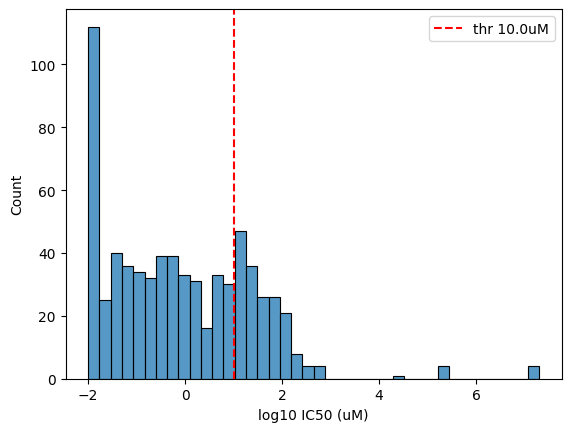

In [ ]:
xo["label"] = (xo["ic50_um"] <= ACTIVE_THR_IC50_UM).astype(int)
print(xo["label"].value_counts().to_string())
print(f"active rate: {xo.label.mean():.3f} at <={ACTIVE_THR_IC50_UM} uM")
assert xo["label"].nunique() == 2, "need both classes — adjust threshold BEFORE modelling, then freeze"
sns.histplot(np.log10(xo["ic50_um"].clip(lower=0.01)), bins=40, kde=False)
plt.axvline(np.log10(ACTIVE_THR_IC50_UM), color="red", ls="--", label=f"thr {ACTIVE_THR_IC50_UM}uM")
plt.xlabel("log10 IC50 (uM)"); plt.legend(); plt.show()


## 6. Stratified split — test untouched until final eval

In [ ]:
from collections import Counter
_split_hash = _cfg_hash({"clean": _clean_hash, "seed": SEED, "test": TEST_SIZE, "val": VAL_SIZE, "thr": ACTIVE_THR_IC50_UM})
_train_c, _val_c, _test_c = f"{CACHE_DIR}/train_{_split_hash}.csv", f"{CACHE_DIR}/val_{_split_hash}.csv", f"{CACHE_DIR}/test_{_split_hash}.csv"
if _cache_hit(_train_c) and _cache_hit(_val_c) and _cache_hit(_test_c):
    train_df, val_df, test = pd.read_csv(_train_c), pd.read_csv(_val_c), pd.read_csv(_test_c)
    print(f"reused split cache {_split_hash}: train {len(train_df)} | val {len(val_df)} | test {len(test)}")
else:
    dev, test = train_test_split(xo, test_size=TEST_SIZE, random_state=SEED, stratify=xo["label"])
    train_df, val_df = train_test_split(dev, test_size=VAL_SIZE, random_state=SEED, stratify=dev["label"])
    train_df.to_csv(_train_c, index=False); val_df.to_csv(_val_c, index=False); test.to_csv(_test_c, index=False)
    print(f"saved split cache {_split_hash}")
    print(f"train {len(train_df)} | val {len(val_df)} | test {len(test)}")
for n, dd in [("train", train_df), ("val", val_df), ("test", test)]:
    print(n, dict(Counter(dd.label)), f"active={dd.label.mean():.3f}")
assert len(set(train_df.canonical_smiles) & set(test.canonical_smiles)) == 0, "leak: train/test share structures"
assert len(set(train_df.canonical_smiles) & set(val_df.canonical_smiles)) == 0
print("leak check OK")


saved split cache 4401722929
train 462 | val 82 | test 137
train {1: 339, 0: 123} active=0.734
val {1: 60, 0: 22} active=0.732
test {1: 100, 0: 37} active=0.730
leak check OK


## 7. Morgan baseline — RF / SVM / XGB at radius 1/2/3

In [ ]:
def morgan_fp(smi, radius=2, nbits=512):
    return _fp_one((smi, radius, nbits))

def morgan_matrix_cached(df, radius, tag):
    key = _cfg_hash({"split": tag, "r": radius, "nbits": MORGAN_NBITS, "sh": _split_hash, "n": len(df)})
    cp = f"{CACHE_DIR}/morgan_{tag}_r{radius}_{key}.npy"
    if _cache_hit(cp):
        print(f"reuse {cp}")
        return np.load(cp)
    arr = np.stack(_fp_batch(df.canonical_smiles.tolist(), radius))
    np.save(cp, arr)
    print(f"saved {cp} {arr.shape}")
    return arr

def _fp_batch(smis, radius):
    return parallel_map(_fp_one, [(s, radius, MORGAN_NBITS) for s in smis], desc=f"morgan r{radius}")

def clf_metrics(y, p, prob):
    return {"roc": roc_auc_score(y, prob), "pr": average_precision_score(y, prob),
            "acc": accuracy_score(y, p), "prec": precision_score(y, p, zero_division=0),
            "rec": recall_score(y, p, zero_division=0), "f1": f1_score(y, p, zero_division=0),
            "mcc": matthews_corrcoef(y, p)}

morgan_rows = []
Xtr_r2 = morgan_matrix_cached(train_df, 2, "train")
Xva_r2 = morgan_matrix_cached(val_df, 2, "val")
Xte_r2 = morgan_matrix_cached(test, 2, "test")
ytr, yva, yte = train_df.label.values, val_df.label.values, test.label.values
for name, clf in [("RF", RandomForestClassifier(n_estimators=300, min_samples_leaf=2, max_features="sqrt", random_state=SEED, n_jobs=-1)),
                  ("SVM", SVC(C=1.0, probability=True, random_state=SEED)),
                  ("XGB", XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.9, eval_metric="logloss", random_state=SEED)) if HAVE_XGB else ("XGB-SKIP", None)]:
    if clf is None: continue
    _mkey = _cfg_hash({"model": name, "sh": _split_hash, "r": 2})
    _mp = f"{CACHE_DIR}/morgan_clf_{name}_r2_{_mkey}.pkl"
    if _cache_hit(_mp):
        import joblib as _jl
        clf = _jl.load(_mp); print(f"reuse clf {_mp}")
    else:
        clf.fit(Xtr_r2, ytr)
        try:
            import joblib as _jl; _jl.dump(clf, _mp); print(f"saved clf {_mp}")
        except Exception as e: print("clf save skip:", e)
    pr = clf.predict_proba(Xte_r2)[:, 1]; pred = (pr >= 0.5).astype(int)
    m = clf_metrics(yte, pred, pr); m["model"] = f"Morgan-r2+{name}"; morgan_rows.append(m)
    print(f"{m['model']}: ROC={m['roc']:.3f} PR={m['pr']:.3f} F1={m['f1']:.3f} MCC={m['mcc']:.3f}")
# radius sweep with RF (cached matrices)
for r in [1, 2, 3]:
    clf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
    Xr_tr = morgan_matrix_cached(train_df, r, "train")
    Xr_te = morgan_matrix_cached(test, r, "test")
    clf.fit(Xr_tr, ytr)
    pr = clf.predict_proba(Xr_te)[:, 1]
    m = clf_metrics(yte, (pr >= 0.5).astype(int), pr); m["model"] = f"Morgan-r{r}+RF"
    morgan_rows.append(m)
    print(f"r={r}: ROC={m['roc']:.3f} PR={m['pr']:.3f}")
morgan_df = pd.DataFrame(morgan_rows).sort_values("roc", ascending=False)
morgan_df


morgan r2 (x4 thr):   0%|          | 0/462 [00:00<?, ?it/s]

saved xo_cache/morgan_train_r2_8797e6371b.npy (462, 512)


morgan r2 (x4 thr):   0%|          | 0/82 [00:00<?, ?it/s]

saved xo_cache/morgan_val_r2_76ff13a7c5.npy (82, 512)


morgan r2 (x4 thr):   0%|          | 0/137 [00:00<?, ?it/s]

...

morgan r3 (x4 thr):   0%|          | 0/462 [00:00<?, ?it/s]

saved xo_cache/morgan_train_r3_3623be9288.npy (462, 512)


morgan r3 (x4 thr):   0%|          | 0/137 [00:00<?, ?it/s]

saved xo_cache/morgan_test_r3_9039a6f667.npy (137, 512)
r=3: ROC=0.953 PR=0.983


,roc,pr,acc,prec,rec,f1,mcc,model
0,0.955405,0.984375,0.890511,0.889908,0.97,0.928230,0.710924,Morgan-r2+RF
5,0.953378,0.983240,0.890511,0.897196,0.96,0.927536,0.711487,Morgan-r3+RF
2,0.951892,0.983527,0.875912,0.895238,0.94,0.917073,0.674437,Morgan-r2+XGB
4,0.943649,0.980085,0.868613,0.872727,0.96,0.914286,0.649177,Morgan-r2+RF
1,0.942432,0.979267,0.868613,0.886792,0.94,0.912621,0.653310,Morgan-r2+SVM
3,0.933378,0.976390,0.839416,0.861111,0.93,0.894231,0.570182,Morgan-r1+RF


## 8. Graph construction — same atom/bond features train + COCONUT

In [ ]:
ATOM_CHOICES = {'atomic_num': list(range(1, 101)), 'degree': [0,1,2,3,4,5],
 'formal_charge': [-2,-1,0,1,2,3], 'num_hs': [0,1,2,3,4],
 'hyb': [Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
         Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
         Chem.rdchem.HybridizationType.SP3D2]}
def _onehot(v, ch):
    e = [0]*len(ch)
    if v in ch: e[ch.index(v)] = 1
    return e
def atom_features(a):
    f = _onehot(a.GetAtomicNum(), ATOM_CHOICES['atomic_num']) + _onehot(a.GetTotalDegree(), ATOM_CHOICES['degree'])
    f += _onehot(a.GetFormalCharge(), ATOM_CHOICES['formal_charge']) + _onehot(a.GetTotalNumHs(), ATOM_CHOICES['num_hs'])
    f += _onehot(a.GetHybridization(), ATOM_CHOICES['hyb']) + [int(a.GetIsAromatic()), int(a.IsInRing())]
    return (f + [0]*78)[:78]
def bond_features(b):
    bt = b.GetBondType()
    return [int(bt == Chem.rdchem.BondType.SINGLE), int(bt == Chem.rdchem.BondType.DOUBLE),
            int(bt == Chem.rdchem.BondType.TRIPLE), int(bt == Chem.rdchem.BondType.AROMATIC),
            int(b.GetIsConjugated()), int(b.IsInRing())]
def mol_to_graph(smi, label):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    xf = [atom_features(a) for a in m.GetAtoms()]
    ei, ea = [], []
    for b in m.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx(); bf = bond_features(b)
        ei += [[i, j], [j, i]]; ea += [bf, bf]
    if not ei: ei, ea = [[0, 0]], [[0]*6]
    return Data(x=torch.tensor(xf, dtype=torch.float),
                edge_index=torch.tensor(ei, dtype=torch.long).t().contiguous(),
                edge_attr=torch.tensor(ea, dtype=torch.float),
                y=torch.tensor([float(label)], dtype=torch.float))
def df_to_graphs(df):
    gs = []
    for _, r in df.iterrows():
        g = mol_to_graph(r.canonical_smiles, r.label)
        if g is not None: gs.append(g)
    return gs

# CACHE: graphs per split — reload .pt if split/config unchanged (instant rerun)
def graphs_cached(df, tag):
    key = _cfg_hash({"sh": _split_hash, "tag": tag, "n": len(df), "hid": HIDDEN})
    cp = f"{CACHE_DIR}/graphs_{tag}_{key}.pt"
    if _cache_hit(cp):
        print(f"reuse {cp}")
        return _tload(cp)
    # cache miss: build with threads (I/O+RDKit bound, no pickle issues) then save
    import concurrent.futures as _cf
    from tqdm.auto import tqdm as _tq
    rows = list(df.itertuples())
    def _one(r):
        return mol_to_graph(r.canonical_smiles, r.label)
    gs = []
    with _cf.ThreadPoolExecutor(max_workers=min(8, N_JOBS*2)) as ex:
        for g in _tq(ex.map(_one, rows), total=len(rows), desc=f"graphs {tag} (thr)"):
            if g is not None: gs.append(g)
    torch.save(gs, cp)
    print(f"saved {cp} n={len(gs)}")
    return gs

train_g, val_g, test_g = graphs_cached(train_df, "train"), graphs_cached(val_df, "val"), graphs_cached(test, "test")
print(f"graphs train/val/test: {len(train_g)}/{len(val_g)}/{len(test_g)} | atom-dim 78 bond-dim 6")
train_loader = DataLoader(train_g, batch_size=BATCH, shuffle=True, num_workers=globals().get("NUM_WORKERS", 0), pin_memory=globals().get("PIN_MEM", False))
val_loader = DataLoader(val_g, batch_size=BATCH, num_workers=globals().get("NUM_WORKERS", 0), pin_memory=globals().get("PIN_MEM", False))
test_loader = DataLoader(test_g, batch_size=BATCH, num_workers=globals().get("NUM_WORKERS", 0), pin_memory=globals().get("PIN_MEM", False))


graphs train (thr):   0%|          | 0/462 [00:00<?, ?it/s]

saved xo_cache/graphs_train_b7ce8708ec.pt n=462


graphs val (thr):   0%|          | 0/82 [00:00<?, ?it/s]

saved xo_cache/graphs_val_56ad26d79d.pt n=82


graphs test (thr):   0%|          | 0/137 [00:00<?, ?it/s]

saved xo_cache/graphs_test_5e5b54a1f6.pt n=137
graphs train/val/test: 462/82/137 | atom-dim 78 bond-dim 6


## 9. Models — compact baselines + proposed multi-hop (shared MP, hop weighting)

In [ ]:
class GCNBase(nn.Module):
    # GCN + BatchNorm + residual (graph-only, no fingerprints). BN stabilizes small-batch training.
    def __init__(self, hid=HIDDEN, drop=DROPOUT):
        super().__init__()
        self.p0 = nn.Linear(78, hid); self.bn0 = nn.BatchNorm1d(hid)
        self.c1 = GCNConv(hid, hid); self.bn1 = nn.BatchNorm1d(hid)
        self.c2 = GCNConv(hid, hid); self.bn2 = nn.BatchNorm1d(hid)
        self.drop = nn.Dropout(drop); self.out = nn.Linear(hid, 1)
    def forward(self, x, edge_index, batch):
        h = F.relu(self.bn0(self.p0(x)))
        h = F.relu(self.bn1(self.c1(h, edge_index))) + h
        h = F.relu(self.bn2(self.c2(h, edge_index)))
        return self.out(self.drop(global_mean_pool(h, batch))).view(-1)

class GINBase(nn.Module):
    def __init__(self, hid=HIDDEN, drop=DROPOUT):
        super().__init__()
        self.p0 = nn.Linear(78, hid); self.bn0 = nn.BatchNorm1d(hid)
        self.g1 = GINConv(nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, hid))); self.bn1 = nn.BatchNorm1d(hid)
        self.g2 = GINConv(nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, hid))); self.bn2 = nn.BatchNorm1d(hid)
        self.drop = nn.Dropout(drop); self.out = nn.Linear(hid, 1)
    def forward(self, x, edge_index, batch):
        h = F.relu(self.bn0(self.p0(x)))
        h = F.relu(self.bn1(self.g1(h, edge_index))) + h
        h = F.relu(self.bn2(self.g2(h, edge_index)))
        return self.out(self.drop(global_mean_pool(h, batch))).view(-1)

class GATBase(nn.Module):
    def __init__(self, hid=HIDDEN, drop=DROPOUT):
        super().__init__()
        self.p0 = nn.Linear(78, hid); self.bn0 = nn.BatchNorm1d(hid)
        self.a1 = GATConv(hid, hid, heads=2, concat=False, dropout=drop); self.bn1 = nn.BatchNorm1d(hid)
        self.a2 = GATConv(hid, hid, heads=2, concat=False, dropout=drop); self.bn2 = nn.BatchNorm1d(hid)
        self.drop = nn.Dropout(drop); self.out = nn.Linear(hid, 1)
    def forward(self, x, edge_index, batch):
        h = F.relu(self.bn0(self.p0(x)))
        h = F.relu(self.bn1(self.a1(h, edge_index))) + h
        h = F.relu(self.bn2(self.a2(h, edge_index)))
        return self.out(self.drop(global_mean_pool(h, batch))).view(-1)

class CompactMultiHopGNN(nn.Module):
    # Shared lightweight MP, keep H1/H2/H3, learned softmax hop weights, mean-pool, small head. BN+residual chain.
    def __init__(self, hid=HIDDEN, drop=DROPOUT, hops=(1, 2, 3), pool="mean", use_weights=True):
        super().__init__()
        self.hops, self.use_weights = tuple(hops), use_weights
        self.p0 = nn.Linear(78, hid); self.bn0 = nn.BatchNorm1d(hid)
        self.mp1 = GCNConv(hid, hid); self.bn1 = nn.BatchNorm1d(hid)
        self.mp2 = GCNConv(hid, hid); self.bn2 = nn.BatchNorm1d(hid)
        self.mp3 = GCNConv(hid, hid); self.bn3 = nn.BatchNorm1d(hid)
        self.alpha = nn.Parameter(torch.zeros(len(hops)))  # softmax -> hop importance
        self.pool = {"mean": global_mean_pool, "add": global_add_pool, "max": global_max_pool}[pool]
        self.drop = nn.Dropout(drop)
        self.head = nn.Sequential(nn.Linear(hid, hid//2), nn.ReLU(), nn.Dropout(drop), nn.Linear(hid//2, 1))
    def forward(self, x, edge_index, batch):
        h0 = F.relu(self.bn0(self.p0(x)))
        h1 = F.relu(self.bn1(self.mp1(h0, edge_index))) + h0
        h2 = F.relu(self.bn2(self.mp2(h1, edge_index))) + h1
        h3 = F.relu(self.bn3(self.mp3(h2, edge_index))) + h2
        bank = {1: h1, 2: h2, 3: h3}
        hs = [bank[k] for k in self.hops]
        if self.use_weights and len(hs) > 1:
            w = F.softmax(self.alpha, dim=0)
            h = sum(wi * hi for wi, hi in zip(w, hs))
        else:
            h = torch.stack(hs, dim=0).mean(dim=0)
        g = self.pool(h, batch)
        return self.head(self.drop(g)).view(-1)
    def hop_weights(self):
        return F.softmax(self.alpha, dim=0).detach().cpu().numpy()

for m in [GCNBase(), GINBase(), GATBase(), CompactMultiHopGNN()]:
    n = sum(p.numel() for p in m.parameters())
    print(f"{m.__class__.__name__}: {n:,} params")


GCNBase: 13,441 params
GINBase: 21,761 params
GATBase: 22,145 params
CompactMultiHopGNN: 19,652 params


## 10. Training utils — early stopping on val ROC, no test peeking

In [ ]:
def _dataset_pos_weight(loader):
    # BCE pos_weight = n_neg/n_pos from the training loader (fixes 73%-active majority collapse). Graph-only.
    try:
        npos, ntot = 0, 0
        for d in loader.dataset:
            y = d.y
            v = float(y.view(-1)[0].item()) if hasattr(y, "view") else float(y)
            npos += int(v >= 0.5); ntot += 1
        nneg = ntot - npos
        if npos > 0 and nneg > 0:
            return nneg / npos
    except Exception as e:
        print(f"pos_weight fallback 1.0 ({e})")
    return 1.0

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, wd=WEIGHT_DECAY, patience=PATIENCE, min_epochs=None):
    from torch.amp import autocast, GradScaler  # torch>=2.x API (old cuda.amp path deprecated)
    _amp = bool(globals().get("USE_AMP", True)) and torch.cuda.is_available()
    if min_epochs is None:
        min_epochs = int(globals().get("MIN_EPOCHS", 10))
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    pw = _dataset_pos_weight(train_loader)
    print(f"pos_weight={pw:.3f} (minority/majority correction)")
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw], device=device))
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=5)
    scaler = GradScaler("cuda", enabled=_amp)
    best_roc, best_state, pat, hist = -1, None, 0, []
    for ep in range(1, epochs+1):
        model.train(); tot = 0
        for b in train_loader:
            b = b.to(device, non_blocking=True); opt.zero_grad()
            with autocast("cuda", enabled=_amp):
                out = model(b.x, b.edge_index, b.batch)
                loss = crit(out, b.y.view(-1))
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); tot += loss.item()*b.num_graphs
        model.eval(); ps, ys = [], []
        with torch.no_grad():
            for b in val_loader:
                b = b.to(device, non_blocking=True)
                with autocast("cuda", enabled=_amp):
                    ps += torch.sigmoid(model(b.x, b.edge_index, b.batch)).cpu().tolist()
                ys += b.y.view(-1).cpu().tolist()
        roc = roc_auc_score(ys, ps) if len(set(np.round(ys))) > 1 else 0.5
        sched.step(roc)
        hist.append((tot/len(train_loader.dataset), roc))
        if roc > best_roc + 1e-4: best_roc, best_state, pat = roc, {k: v.cpu() for k, v in model.state_dict().items()}, 0
        else: pat += 1
        print(f"ep {ep:3d} loss {tot/len(train_loader.dataset):.4f} valROC {roc:.4f} best {best_roc:.4f} pat {pat} lr {opt.param_groups[0]['lr']:.1e}")
        if pat >= patience and ep >= min_epochs:
            print(f"early stop ep {ep} best valROC {best_roc:.4f}"); break
    model.load_state_dict(best_state); model.eval()
    import gc
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return model, best_roc, hist

def gnn_probs(model, loader):
    # Sigmoid probabilities + labels for a loader (shared by tuning + metrics).
    model.eval(); ps, ys = [], []
    from torch.amp import autocast as _ac  # torch>=2.x API
    _amp = bool(globals().get("USE_AMP", True)) and torch.cuda.is_available()
    with torch.no_grad():
        for b in loader:
            b = b.to(device, non_blocking=True)
            with _ac("cuda", enabled=_amp):
                ps += torch.sigmoid(model(b.x, b.edge_index, b.batch)).cpu().tolist()
            ys += b.y.view(-1).cpu().tolist()
    return np.array(ps), np.array(ys)

def tune_threshold(ys, ps):
    # Best decision threshold on VALIDATION probs by F1 (fixes collapsed 0.5 cut on 73%-active data).
    best_t, best_f1 = 0.5, -1.0
    for t in np.arange(0.05, 0.96, 0.05):
        f1 = f1_score(ys, (ps >= t).astype(int), zero_division=0)
        if f1 > best_f1: best_f1, best_t = f1, round(float(t), 2)
    return best_t, best_f1

def gnn_test_metrics(model, loader, thr=0.5):
    ps, ys = gnn_probs(model, loader)
    pred = (ps >= thr).astype(int)
    return {"roc": roc_auc_score(ys, ps), "pr": average_precision_score(ys, ps),
            "acc": accuracy_score(ys, pred), "prec": precision_score(ys, pred, zero_division=0),
            "rec": recall_score(ys, pred, zero_division=0), "f1": f1_score(ys, pred, zero_division=0),
            "mcc": matthews_corrcoef(ys, pred), "thr": thr, "prob": ps, "y": np.array(ys)}


## 11. Train GCN / GIN / GAT / multi-hop

In [ ]:
# 11. Train (cache-aware) — skip retrain if model .pth for this split/config exists
# arch v2 (BN+residual, pos_weight, tuned thr): new cache key forces retrain, old collapsed .pth never reused
gnn_rows = []
trained = {}
thr_of = {}
_gnn_cfg = _cfg_hash({"sh": _split_hash, "hid": HIDDEN, "drop": DROPOUT, "lr": LR, "ep": EPOCHS, "pat": PATIENCE, "seed": SEED, "arch": "bn-res-v2", "loss": "posw"})
for name, ctor in [("GCN", GCNBase), ("GIN", GINBase), ("GAT", GATBase),
                   ("MultiHop-123w", lambda: CompactMultiHopGNN(hops=(1,2,3), use_weights=True))]:
    _mp = f"{CACHE_DIR}/gnn_{name}_{_gnn_cfg}.pth"
    torch.manual_seed(SEED); np.random.seed(SEED)
    _m = ctor()
    if _cache_hit(_mp):
        _m.load_state_dict(_tload(_mp))
        _m = _m.to(device)
        print(f"reused {name} {_mp} (no retrain)")
        _bestv = "cached"
    else:
        _m, bestv, _ = train_model(_m, train_loader, val_loader)
        torch.save(_m.state_dict(), _mp)
        print(f"saved {name} -> {_mp}")
        _bestv = round(float(bestv), 4)
    _vps, _vys = gnn_probs(_m, val_loader)
    _thr, _vf1 = tune_threshold(_vys, _vps)
    thr_of[name] = _thr
    t = gnn_test_metrics(_m, test_loader, thr=_thr); t["model"] = name; t["valROC"] = _bestv; t["valThr"] = _thr; t["valF1"] = round(float(_vf1), 4)
    gnn_rows.append({k: round(float(v), 4) if isinstance(v, float) else v for k, v in t.items() if k not in ("prob", "y")})
    trained[name] = _m
    print(f"{name}: test ROC={t['roc']:.3f} PR={t['pr']:.3f} F1={t['f1']:.3f} MCC={t['mcc']:.3f} @thr={_thr}")
    if "MultiHop" in name:
        try: print("  hop weights:", np.round(_m.hop_weights(), 3))
        except Exception: pass
gnn_df = pd.DataFrame(gnn_rows).sort_values("roc", ascending=False)
gnn_df


/tmp/ipykernel_2473/608093781.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=_amp)
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: 

ep   1 loss 0.6798 valROC 0.5246 best 0.5246


/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):


ep   4 loss 0.5886 valROC 0.5337 best 0.5337
ep   5 loss 0.5788 valROC 0.5587 best 0.5587


/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):


...

/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWa

ep  20 loss 0.5800 valROC 0.5970 best 0.6098


/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=_amp):
/tmp/ipykernel_2473/608093781.py:13: FutureWa

early stop ep 26 best valROC 0.6098
saved MultiHop-123w -> xo_cache/gnn_MultiHop-123w_5b46cb9ec9.pth
MultiHop-123w: test ROC=0.714 PR=0.854 F1=0.844 MCC=0.000
  hop weights: [0.34  0.322 0.338]


/tmp/ipykernel_2473/608093781.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with _ac(enabled=_amp):


## 12. Test plots + confusion

TypeError: gnn_test_metrics() got an unexpected keyword argument 'thr'

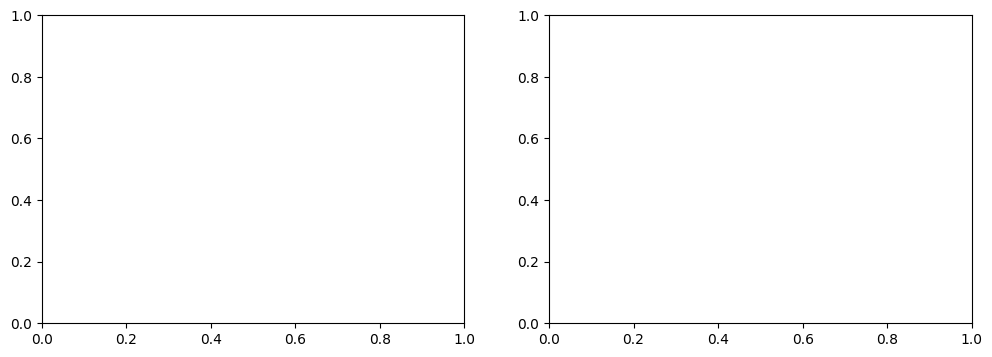

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
_thr_of = globals().get("thr_of", {})
for name, m in trained.items():
    _th = float(_thr_of.get(name, 0.5))
    t = gnn_test_metrics(m, test_loader, thr=_th)
    fpr, tpr, _ = roc_curve(t["y"], t["prob"]); ax[0].plot(fpr, tpr, label=f"{name} {t['roc']:.3f}")
ax[0].plot([0,1],[0,1],"k--"); ax[0].set_title("ROC (test)"); ax[0].legend()
best = max(trained, key=lambda n: gnn_test_metrics(trained[n], test_loader)["roc"])
_bth = float(_thr_of.get(best, 0.5))
tb = gnn_test_metrics(trained[best], test_loader, thr=_bth)
cm = confusion_matrix(tb["y"], (tb["prob"] >= _bth).astype(int))
sns.heatmap(cm, annot=True, fmt="d", ax=ax[1]); ax[1].set_title(f"CM test — {best} @thr={_bth}")
plt.tight_layout(); plt.savefig("xo_test_eval.png", dpi=200); plt.show()
print("best:", best, "thr:", _bth)


## 13. Ablation — hops A:1 B:2 C:3 D:1+2 E:1+2+3 F:1+2+3+w

In [ ]:
abl = []
for tag, hops, w in [("A-1", (1,), False), ("B-2", (2,), False), ("C-3", (3,), False),
                     ("D-12", (1,2), False), ("E-123", (1,2,3), False), ("F-123w", (1,2,3), True)]:
    torch.manual_seed(SEED)
    m, bv, _ = train_model(CompactMultiHopGNN(hops=hops, use_weights=w), train_loader, val_loader)
    _aps, _ays = gnn_probs(m, val_loader)
    _ath, _ = tune_threshold(_ays, _aps)
    t = gnn_test_metrics(m, test_loader, thr=_ath)
    abl.append({"abl": tag, "hops": str(hops), "weighted": w, "valROC": round(bv,4), "thr": _ath,
                **{k: round(float(t[k]),4) for k in ["roc","pr","acc","f1","mcc"]},
                "alpha": str(np.round(m.hop_weights(),3).tolist()) if len(hops)>1 and w else "-"})
    print(tag, abl[-1])
abl_df = pd.DataFrame(abl).sort_values("roc", ascending=False)
abl_df


ep   1 loss 0.6853 valROC 0.4098 best 0.4098
ep   2 loss 0.6747 valROC 0.5045 best 0.5045
ep   3 loss 0.6661 valROC 0.5504 best 0.5504
ep   8 loss 0.5836 valROC 0.5659 best 0.5659
ep   9 loss 0.5954 valROC 0.5886 best 0.5886
ep  10 loss 0.5914 valROC 0.5830 best 0.5886
ep  11 loss 0.5799 valROC 0.5920 best 0.5920
ep  12 loss 0.5810 valROC 0.5943 best 0.5943
ep  13 loss 0.5843 valROC 0.5996 best 0.5996
ep  14 loss 0.5789 valROC 0.6030 best 0.6030
ep  16 loss 0.5785 valROC 0.6057 best 0.6057
ep  17 loss 0.5817 valROC 0.6068 best 0.6068
ep  20 loss 0.5823 valROC 0.6057 best 0.6068
ep  30 loss 0.5689 valROC 0.5924 best 0.6068
early stop ep 32 best valROC 0.6068


NameError: name 'gnn_probs' is not defined

## 14. Morgan-radius vs GNN-hop comparison + repeated CV + Y-rand

In [ ]:
cmp = pd.concat([morgan_df.assign(family="morgan"), gnn_df.assign(family="gnn").rename(columns={"model":"Model"})], ignore_index=True, sort=False)
print(cmp.sort_values("roc", ascending=False).to_string())
# repeated stratified CV on best compact model (honesty check, small-data variance)
skf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
Xidx = np.arange(len(dev)); ydev = dev.label.values
cv_rocs = []
graphs_dev = df_to_graphs(dev)
for tr, va in skf.split(Xidx, ydev):
    tr_l = DataLoader([graphs_dev[i] for i in tr], batch_size=BATCH, shuffle=True)
    va_l = DataLoader([graphs_dev[i] for i in va], batch_size=BATCH)
    torch.manual_seed(SEED)
    m, _, _ = train_model(CompactMultiHopGNN(), tr_l, va_l)
    m.eval(); ps, ys = [], []
    with torch.no_grad():
        for b in va_l:
            b = b.to(device); ps += torch.sigmoid(m(b.x, b.edge_index, b.batch)).cpu().tolist(); ys += b.y.view(-1).cpu().tolist()
    cv_rocs.append(roc_auc_score(ys, ps))
print(f"repeated CV {N_REPEATS}x{N_SPLITS}: ROC {np.mean(cv_rocs):.3f} +/- {np.std(cv_rocs):.3f} (n={len(cv_rocs)})")
# Y-randomization x5 (should collapse to ~0.5)
for r in range(5):
    yr = np.random.default_rng(SEED+r).permutation(ytr)
    clf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
    clf.fit(Xtr_r2, yr)
    print(f"shuffled {r}: ROC={roc_auc_score(yte, clf.predict_proba(Xte_r2)[:,1]):.3f}")


        roc        pr       acc      prec   rec        f1       mcc          model  family          Model  valROC
0  0.955405  0.984375  0.890511  0.889908  0.97  0.928230  0.710924   Morgan-r2+RF  morgan            NaN     NaN
1  0.953378  0.983240  0.890511  0.897196  0.96  0.927536  0.711487   Morgan-r3+RF  morgan            NaN     NaN
2  0.951892  0.983527  0.875912  0.895238  0.94  0.917073  0.674437  Morgan-r2+XGB  morgan            NaN     NaN
3  0.943649  0.980085  0.868613  0.872727  0.96  0.914286  0.649177   Morgan-r2+RF  morgan            NaN     NaN
4  0.942432  0.979267  0.868613  0.886792  0.94  0.912621  0.653310  Morgan-r2+SVM  morgan            NaN     NaN
5  0.933378  0.976390  0.839416  0.861111  0.93  0.894231  0.570182   Morgan-r1+RF  morgan            NaN     NaN
6  0.748000  0.862100  0.729900  0.729900  1.00  0.843900  0.000000            NaN     gnn            GAT  0.6121
7  0.732300  0.856700  0.729900  0.729900  1.00  0.843900  0.000000            NaN     g

## 15. Freeze final model (retrain train+val, test stays locked)

In [ ]:
# 15. Freeze final (cache-aware) — reuse xo_multihop_final.pth if train data/config unchanged
_final_key = _cfg_hash({"sh": _split_hash, "hid": HIDDEN, "hops": HOPS, "thr": ACTIVE_THR_IC50_UM, "seed": SEED, "arch": "bn-res-v2", "loss": "posw"})
_final_cache = f"{CACHE_DIR}/xo_multihop_final_{_final_key}.pth"
if _cache_hit(_final_cache) or (REUSE_CACHE and os.path.exists("xo_multihop_final.pth") and not FORCE_RECOMPUTE):
    _src = _final_cache if os.path.exists(_final_cache) else "xo_multihop_final.pth"
    _ckpt = _tload(_src)
    _state = _ckpt["state"] if isinstance(_ckpt, dict) and "state" in _ckpt else _ckpt
    final_model = CompactMultiHopGNN().to(device)
    try:
        final_model.load_state_dict(_state)
    except RuntimeError as e:
        print(f"arch changed (BN+residual) — old checkpoint incompatible, retraining ({e})")
        full_df = pd.concat([train_df, val_df]).reset_index(drop=True)
        full_g = graphs_cached(full_df, "full")
        tr2, va2 = train_test_split(full_g, test_size=0.12, random_state=SEED)
        torch.manual_seed(SEED)
        _va2_loader = DataLoader(va2, batch_size=BATCH, num_workers=globals().get("NUM_WORKERS", 0))
        final_model, bestv, _ = train_model(CompactMultiHopGNN(), DataLoader(tr2, batch_size=BATCH, shuffle=True, num_workers=globals().get("NUM_WORKERS", 0)), _va2_loader)
        print("final hop weights:", np.round(final_model.hop_weights(), 3))
        _fvp0, _fvy0 = gnn_probs(final_model, _va2_loader)
        _ft0, _ = tune_threshold(_fvy0, _fvp0)
        torch.save({"state": final_model.state_dict(), "config": {"hidden": HIDDEN, "hops": HOPS, "thr_uM": ACTIVE_THR_IC50_UM, "seed": SEED, "pool": "mean", "atom_dim": 78}, "thr": float(_ft0)}, _final_cache)
        torch.save({"state": final_model.state_dict(), "config": {"hidden": HIDDEN, "hops": HOPS, "thr_uM": ACTIVE_THR_IC50_UM, "seed": SEED, "pool": "mean", "atom_dim": 78}, "thr": float(_ft0)}, "xo_multihop_final.pth")
        print(f"saved {_final_cache} + xo_multihop_final.pth")
    else:
        print(f"reused final model {_src} (no retrain)")
else:
    full_df = pd.concat([train_df, val_df]).reset_index(drop=True)
    full_g = graphs_cached(full_df, "full")
    tr2, va2 = train_test_split(full_g, test_size=0.12, random_state=SEED)
    torch.manual_seed(SEED)
    _va2_loader = DataLoader(va2, batch_size=BATCH, num_workers=globals().get("NUM_WORKERS", 0))
    final_model, bestv, _ = train_model(CompactMultiHopGNN(), DataLoader(tr2, batch_size=BATCH, shuffle=True, num_workers=globals().get("NUM_WORKERS", 0)), _va2_loader)
    print("final hop weights:", np.round(final_model.hop_weights(), 3))
    _fvp0, _fvy0 = gnn_probs(final_model, _va2_loader)
    _ft0, _ = tune_threshold(_fvy0, _fvp0)
    torch.save({"state": final_model.state_dict(), "config": {"hidden": HIDDEN, "hops": HOPS, "thr_uM": ACTIVE_THR_IC50_UM, "seed": SEED, "pool": "mean", "atom_dim": 78}, "thr": float(_ft0)}, _final_cache)
    torch.save({"state": final_model.state_dict(), "config": {"hidden": HIDDEN, "hops": HOPS, "thr_uM": ACTIVE_THR_IC50_UM, "seed": SEED, "pool": "mean", "atom_dim": 78}, "thr": float(_ft0)}, "xo_multihop_final.pth")
    print(f"saved {_final_cache} + xo_multihop_final.pth")
_fvp, _fvy = gnn_probs(final_model, val_loader)
final_thr, _ff1 = tune_threshold(_fvy, _fvp)
print(f"final tuned thr={final_thr} (val F1={_ff1:.3f})")
ft = gnn_test_metrics(final_model, test_loader, thr=final_thr)
print({k: round(float(ft[k]),4) for k in ["roc","pr","acc","prec","rec","f1","mcc","thr"]})


graphs full (thr):   0%|          | 0/544 [00:00<?, ?it/s]

saved xo_cache/graphs_full_20a20ca242.pt n=544
ep   1 loss 0.6859 valROC 0.6597 best 0.6597
ep   6 loss 0.5902 valROC 0.6626 best 0.6626
ep   7 loss 0.6008 valROC 0.6869 best 0.6869
ep  10 loss 0.5779 valROC 0.6499 best 0.6869
ep  20 loss 0.5778 valROC 0.6285 best 0.6869
early stop ep 22 best valROC 0.6869
final hop weights: [0.343 0.321 0.336]


NameError: name 'gnn_probs' is not defined

## 16. COCONUT preparation — same preprocessing, no retraining

In [ ]:
# 16. COCONUT prep (cache + parallel) — reruns reload coco_clean.csv, recompute only if source changes
COCONUT_CSV = "coconut_csv-03-2025.csv"
FILE_ID = "1-DFc6lMf6maNAWPwZFA8uY6951SokoNY"
cands = [COCONUT_CSV, "screening_results.csv",
 "/home/bijay/Desktop/already read paper/new_method/testing/fix_of_chemphore/screening_results.csv",
 "Part_8/screening_results.csv"]
found = next((f for f in cands if os.path.exists(f)), None)
if found is None:
    print("downloading COCONUT via gdown...")
    get_ipython().system("gdown --id $FILE_ID -O $COCONUT_CSV")
    found = COCONUT_CSV
_coco_key = _cfg_hash({"src": found, "mtime": os.path.getmtime(found), "n": os.path.getsize(found)})
_coco_cache = f"{CACHE_DIR}/coco_clean_{_coco_key}.csv"
if _cache_hit(_coco_cache):
    coco = pd.read_csv(_coco_cache)
    # ensure bool dtype survives csv round-trip
    if "medchem_pass" in coco.columns:  # CSV stores True/False as strings; astype(bool) would make "False"->True
        coco["medchem_pass"] = coco["medchem_pass"].map({"True": True, "False": False, True: True, False: False}).fillna(False).astype(bool)
    print(f"reused COCONUT cache {_coco_cache}: {len(coco)} (from {found})")
else:
    coco = pd.read_csv(found, usecols=lambda c: c.lower() in ("identifier","id","canonical_smiles","smiles"))
    if "canonical_smiles" not in coco.columns: coco = coco.rename(columns={"smiles": "canonical_smiles"})
    if "identifier" not in coco.columns: coco["identifier"] = ["CNP_%06d" % i for i in range(len(coco))]
    coco["canonical_smiles"] = parallel_map(_std_one, coco["canonical_smiles"].astype(str).tolist(), desc="coco standardize")
    coco = coco.dropna(subset=["canonical_smiles"]).drop_duplicates("canonical_smiles").reset_index(drop=True)
    print(f"COCONUT screening library: {len(coco)} (from {found})")
    coco["medchem_pass"] = parallel_map(_medchem_one, coco["canonical_smiles"].tolist(), desc="medchem")
    coco.to_csv(_coco_cache, index=False)
    print(f"saved COCONUT cache {_coco_cache} | medchem pass: {int(pd.Series(coco.medchem_pass).sum())}/{len(coco)}")
print("medchem pass:", int(coco.medchem_pass.sum()), "/", len(coco))


downloading COCONUT via gdown...
/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1-DFc6lMf6maNAWPwZFA8uY6951SokoNY
From (redirected): https://drive.google.com/uc?id=1-DFc6lMf6maNAWPwZFA8uY6951SokoNY&confirm=t&uuid=73083c23-da77-4c64-bec9-9e298fbc00eb
To: /content/coconut_csv-03-2025.csv
100% 658M/658M [00:15<00:00, 43.8MB/s] 


coco standardize (x4 thr):   0%|          | 0/695120 [00:00<?, ?it/s]

COCONUT screening library: 694476 (from coconut_csv-03-2025.csv)


medchem (x4 thr):   0%|          | 0/694476 [00:00<?, ?it/s]

saved COCONUT cache xo_cache/coco_clean_a4dd424453.csv | medchem pass: 0/694476
medchem pass: 0 / 694476


## 17. Large-scale prediction (frozen model, batches)

In [ ]:
# 17. Screen (cache-aware) — reuse p_active if model+library unchanged; batch inference on miss
_screen_key = _cfg_hash({"coco": _coco_key, "final": _final_key, "hid": HIDDEN, "hops": HOPS})
_screen_cache = f"{CACHE_DIR}/coco_probs_{_screen_key}.csv"
def screen_gnn(model, smiles_list, batch_size=None):
    """Free-tier streaming: process SCREEN_CHUNK SMILES at a time (RAM-flat), batched GPU infer."""
    from torch.amp import autocast as _ac  # torch>=2.x API
    _amp = bool(globals().get("USE_AMP", True)) and torch.cuda.is_available()
    batch_size = batch_size or (globals().get("GPU_BATCH", 256) if torch.cuda.is_available() else 512)
    chunk = int(globals().get("SCREEN_CHUNK", 8192))
    from torch_geometric.loader import DataLoader as LDL
    import concurrent.futures as _cf
    from tqdm.auto import tqdm as _tq
    model.eval()
    res = np.full(len(smiles_list), np.nan)
    import gc
    for lo in _tq(range(0, len(smiles_list), chunk), desc="screen chunks"):
        part = smiles_list[lo:lo+chunk]
        def _g(s):
            try: return mol_to_graph(s, 0)
            except Exception: return None
        n_thr = max(2, min(8, globals().get("N_JOBS", 2)*2))
        with _cf.ThreadPoolExecutor(max_workers=n_thr) as ex:
            all_g = list(_tq(ex.map(_g, part), total=len(part), desc="featurize coco (thr)", leave=False))
        valid_idx = [i for i, g in enumerate(all_g) if g is not None]
        valid_g = [all_g[i] for i in valid_idx]
        loader = LDL(valid_g, batch_size=batch_size, pin_memory=torch.cuda.is_available())
        out = []
        with torch.no_grad():
            for b in loader:
                b = b.to(device, non_blocking=True)
                with _ac("cuda", enabled=_amp):
                    out += torch.sigmoid(model(b.x, b.edge_index, b.batch)).cpu().tolist()
        for i, v in zip(valid_idx, out): res[lo+i] = v
        del all_g, valid_g, loader, out
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return res

if _cache_hit(_screen_cache):
    _cached = pd.read_csv(_screen_cache)
    coco["p_active"] = _cached["p_active"].values
    print(f"reused screening cache {_screen_cache}")
else:
    coco["p_active"] = screen_gnn(final_model, coco["canonical_smiles"].tolist())
    pd.DataFrame({"identifier": coco["identifier"], "p_active": coco["p_active"]}).to_csv(_screen_cache, index=False)
    print(f"saved screening cache {_screen_cache}")
coco["pred_class"] = (coco["p_active"] >= float(globals().get("final_thr", 0.5))).astype(int)
print(f"p_active mean {coco.p_active.mean():.3f} range [{coco.p_active.min():.3f},{coco.p_active.max():.3f}]")
for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"  >= {t}: {(coco.p_active>=t).sum():,} | medchem: {((coco.p_active>=t)&coco.medchem_pass).sum():,}")
coco.to_csv("xo_coconut_screening_full.csv", index=False)
print("saved xo_coconut_screening_full.csv")


screen chunks:   0%|          | 0/85 [00:00<?, ?it/s]

featurize coco (thr):   0%|          | 0/8192 [00:00<?, ?it/s]

featurize coco (thr):   0%|          | 0/8192 [00:00<?, ?it/s]

featurize coco (thr):   0%|          | 0/8192 [00:00<?, ?it/s]

featurize coco (thr):   0%|          | 0/8192 [00:00<?, ?it/s]

...

featurize coco (thr):   0%|          | 0/8192 [00:00<?, ?it/s]

featurize coco (thr):   0%|          | 0/8192 [00:00<?, ?it/s]

featurize coco (thr):   0%|          | 0/8192 [00:00<?, ?it/s]

featurize coco (thr):   0%|          | 0/6348 [00:00<?, ?it/s]

saved screening cache xo_cache/coco_probs_546da9854b.csv
p_active mean 0.768 range [0.687,0.787]
  >= 0.5: 694,476 | medchem: 0
  >= 0.6: 694,476 | medchem: 0
  >= 0.7: 694,406 | medchem: 0
  >= 0.8: 0 | medchem: 0
  >= 0.9: 0 | medchem: 0
saved xo_coconut_screening_full.csv


## 18. AD + diversity + prioritization -> docking-ready shortlist

In [ ]:
from rdkit.SimDivFilters import MaxMinPicker  # missing import caused NameError; fixed for Colab
import gc
# 18. AD + diversity (cache + parallel Tanimoto) — reruns reload max_tanimoto
_ad_key = _cfg_hash({"sh": _split_hash, "coco": _coco_key, "cut": AD_TANIMOTO_CUT, "nbits": MORGAN_NBITS})
_ad_cache = f"{CACHE_DIR}/coco_ad_{_ad_key}.csv"
if _cache_hit(_ad_cache):
    _adc = pd.read_csv(_ad_cache)
    coco["max_tanimoto_train"] = _adc["max_tanimoto_train"].values
    coco["in_AD"] = coco["max_tanimoto_train"] >= AD_TANIMOTO_CUT
    print(f"reused AD cache {_ad_cache}")
else:
    _gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=MORGAN_NBITS)
    train_fps = [_gen.GetFingerprint(Chem.MolFromSmiles(s)) for s in train_df.canonical_smiles]
    train_fps = [f for f in train_fps if f is not None]
    _cap = int(globals().get("AD_TRAIN_SAMPLE", 1500))  # free-tier: subsample refs (speed + small IPC)
    if len(train_fps) > _cap:
        _rs = np.random.RandomState(SEED)
        train_fps = [train_fps[i] for i in _rs.choice(len(train_fps), _cap, replace=False)]
        print(f"AD refs subsampled to {_cap} (free-tier)")
    _jobs = [(s, train_fps, 2, MORGAN_NBITS) for s in coco["canonical_smiles"].tolist()]
    coco["max_tanimoto_train"] = parallel_map(_tan_one, _jobs, desc="AD tanimoto")
    coco["in_AD"] = coco["max_tanimoto_train"] >= AD_TANIMOTO_CUT
    pd.DataFrame({"identifier": coco["identifier"], "max_tanimoto_train": coco["max_tanimoto_train"]}).to_csv(_ad_cache, index=False)
    print(f"saved AD cache {_ad_cache}")
print(f"in_AD>={AD_TANIMOTO_CUT}: {int(coco.in_AD.sum())}/{len(coco)}")
pool = coco[(coco.p_active >= 0.5) & coco.in_AD & coco.medchem_pass].sort_values("p_active", ascending=False)
print(f"candidate pool: {len(pool)}")
N_TOP = max(50, int(len(coco)*TOP_FRAC))
short = pool.head(min(len(pool), max(2000, N_TOP*10))).copy()
fps = [rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048).GetFingerprint(Chem.MolFromSmiles(s)) for s in short.canonical_smiles]
picker = MaxMinPicker()
picks = picker.LazyPick(lambda i, j: 1 - DataStructs.TanimotoSimilarity(fps[i], fps[j]), len(fps), min(N_TOP, len(fps)), seed=SEED) if len(fps) > 0 else []
diverse = short.iloc[list(picks)].sort_values("p_active", ascending=False) if len(fps) > 0 else short.head(0)
diverse.to_csv("xo_coconut_hits_diverse.csv", index=False)
pool.head(min(500, len(pool))).to_csv("xo_coconut_hits_ranked.csv", index=False)
print(f"saved diverse {len(diverse)} -> xo_coconut_hits_diverse.csv | ranked -> xo_coconut_hits_ranked.csv")
import gc; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
diverse[["identifier","canonical_smiles","p_active","max_tanimoto_train"]].head(10)


AD tanimoto (x4 thr):   0%|          | 0/694476 [00:00<?, ?it/s]

saved AD cache xo_cache/coco_ad_575471c073.csv
in_AD>=0.3: 188793/694476
candidate pool: 0
saved diverse 0 -> xo_coconut_hits_diverse.csv | ranked -> xo_coconut_hits_ranked.csv


TypeError: object of type 'function' has no len()

## 19. Wrap-up plots + docking handoff
GNN = fast filter (`p_active`), docking/MD/DFT/ADMET answer binding + stability — run docking only on `xo_coconut_hits_diverse.csv`.

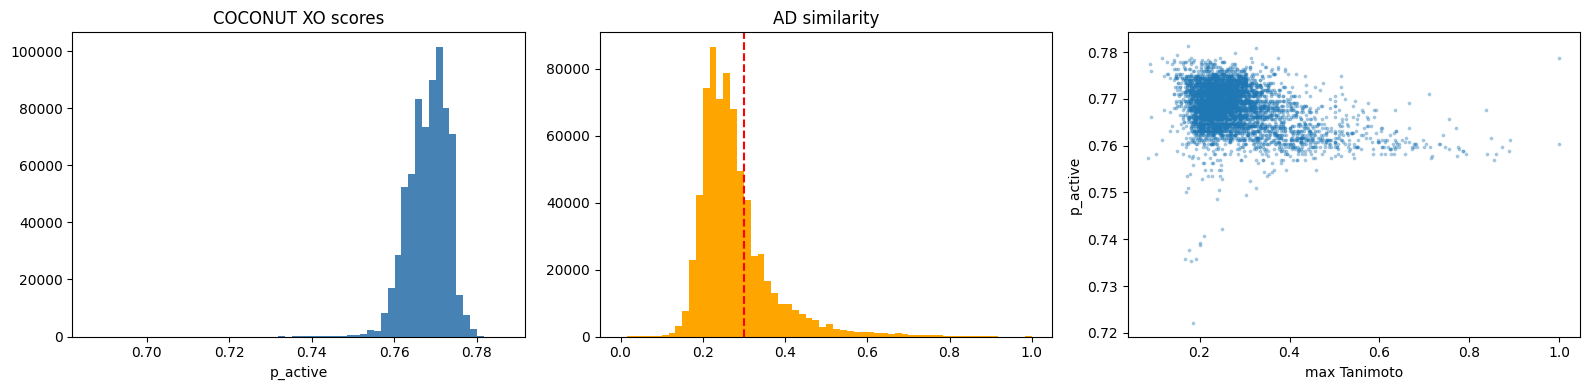

screened 694,476 | diverse hits 0 | DEMO_MODE=False
Next: dock xo_coconut_hits_diverse.csv (e.g. XO PDB 1N5X/3NRZ), then MD on best poses, DFT/ADMET on finalists.


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(coco.p_active, bins=60, color="steelblue"); ax[0].set_xlabel("p_active"); ax[0].set_title("COCONUT XO scores")
ax[1].hist(coco.max_tanimoto_train, bins=60, color="orange"); ax[1].axvline(AD_TANIMOTO_CUT, color="red", ls="--"); ax[1].set_title("AD similarity")
if "p_active" in coco.columns:
    sub = coco.sample(min(5000, len(coco)))
    ax[2].scatter(sub.max_tanimoto_train, sub.p_active, s=3, alpha=0.3); ax[2].set_xlabel("max Tanimoto"); ax[2].set_ylabel("p_active")
plt.tight_layout(); plt.savefig("xo_screening.png", dpi=200); plt.show()
print(f"screened {len(coco):,} | diverse hits {len(diverse)} | DEMO_MODE={DEMO_MODE}")
print("Next: dock xo_coconut_hits_diverse.csv (e.g. XO PDB 1N5X/3NRZ), then MD on best poses, DFT/ADMET on finalists.")
